In [1]:
%pip install PyWavelets scikit-learn matplotlib numpy pillow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [19]:
import pywt
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter
from sklearn.metrics import (accuracy_score, recall_score,
                             confusion_matrix, roc_curve, auc)
from itertools import combinations
import os, requests, io

# ── Hàm mới: Đọc ảnh thật từ thư mục ──────────────────────────────
def load_real_images(folder_path):
    """Đọc toàn bộ ảnh trong thư mục, xử lý sơ bộ và trả về dictionary.
    Key sẽ là tên file KHÔNG gồm phần mở rộng (vd: A1.png -> 'A1').
    """
    images = {}
    
    # Kiểm tra xem thư mục có tồn tại không
    if not os.path.exists(folder_path):
        print(f"Thư mục {folder_path} không tồn tại!")
        return images

    # Duyệt qua các file trong thư mục
    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            file_path = os.path.join(folder_path, filename)
            try:
                # 1. Đọc ảnh -> 2. Chuyển sang ảnh xám (L) -> 3. Resize về 64x64
                img = Image.open(file_path).convert('L').resize((64, 64))
                
                # 4. Chuyển thành Numpy array
                #    Dùng tên file không kèm phần mở rộng làm key (A1.png -> 'A1')
                name, _ = os.path.splitext(filename)
                images[name] = np.array(img)
            except Exception as e:
                print(f"Lỗi khi đọc file {filename}: {e}")
                
    return images

# ==========================================
# CÁCH SỬ DỤNG
# ==========================================
# Cung cấp đường dẫn tới thư mục chứa ảnh của bạn
# Ví dụ: thư mục 'dataset' nằm cùng chỗ với file code
folder_dir = 'dataset' 
images = load_real_images(folder_dir)

print(f"Đã tải thành công {len(images)} ảnh.")

Đã tải thành công 9 ảnh.


In [20]:
def wavelet_hash(image_array, wavelet='haar', level=1, hash_size=64):
    """
    Chuyển ảnh thành binary hash qua Wavelet Transform.
    
    Các bước:
    1. DWT 2D → lấy sub-band LL (approximation)
    2. Lấy 'hash_size' hệ số đầu tiên
    3. Binarize: coeff >= mean → 1, ngược lại → 0
    """
    img = image_array.astype(np.float32)
    
    # DWT 2D: trả về (LL, (LH, HL, HH))
    coeffs = pywt.dwt2(img, wavelet)
    LL, (LH, HL, HH) = coeffs
    
    # Flatten LL và lấy hash_size phần tử đầu
    flat = LL.flatten()[:hash_size]
    
    # Quantize: so sánh với mean
    mean_val = flat.mean()
    binary_hash = (flat >= mean_val).astype(np.uint8)
    
    return binary_hash, LL

def hamming_distance(h1, h2):
    """Đếm số bit khác nhau giữa hai hash."""
    return np.sum(h1 != h2)

# Tính hash cho tất cả ảnh
hashes = {}
LLs = {}
for name, img in images.items():
    h, ll = wavelet_hash(img)
    hashes[name] = h
    LLs[name] = ll

if hashes:
    first_name = next(iter(hashes.keys()))
    print("Hash size:", len(hashes[first_name]))
    print(f"Example hash ({first_name}):", hashes[first_name][:16], "...")
else:
    print("Không có ảnh nào để tính hash.")

Hash size: 64
Example hash (A): [1 1 1 0 1 1 1 0 0 0 0 0 0 0 0 1] ...



Đang hiển thị biểu đồ Wavelet cho ảnh: A


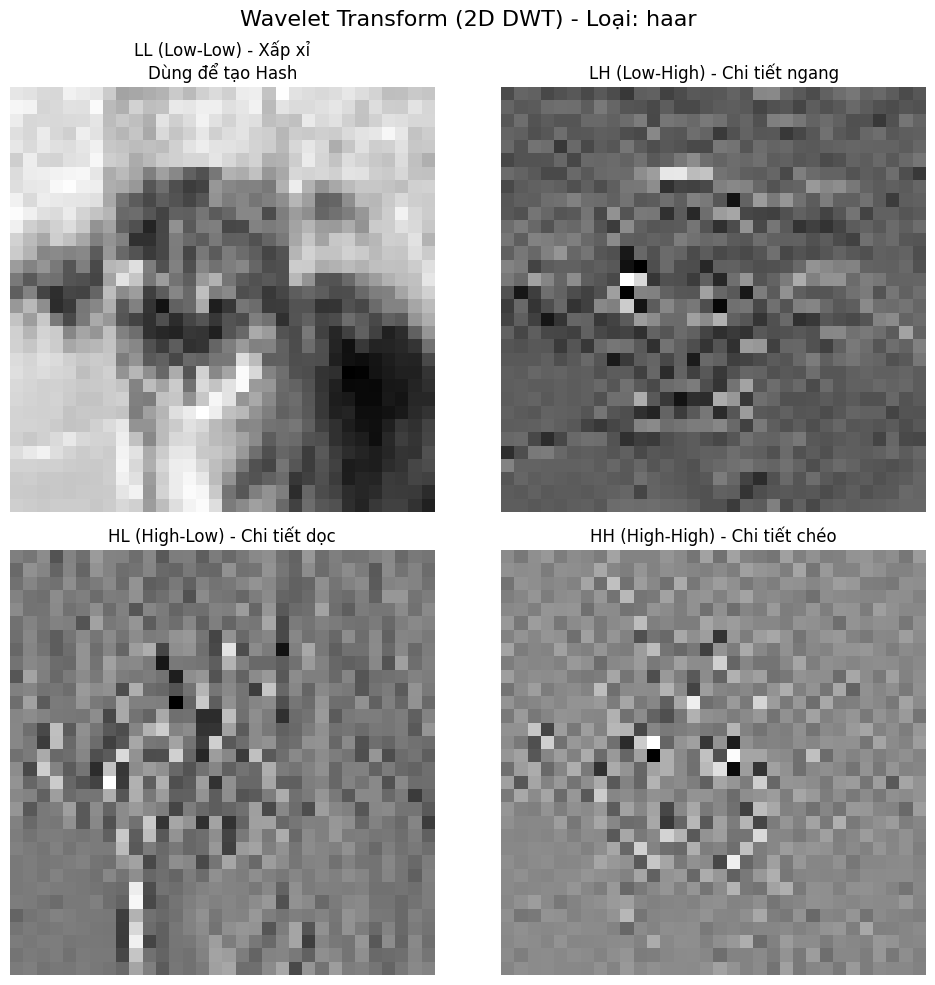

In [27]:
import matplotlib.pyplot as plt

def visualize_wavelet_subbands(image_array, wavelet='haar'):
    """
    Trực quan hóa 4 dải tần (LL, LH, HL, HH) của ảnh qua biến đổi DWT 2D.
    """
    # 1. Đảm bảo ảnh ở dạng 2D (Grayscale)
    if len(image_array.shape) > 2:
        img = image_array[:, :, 0].astype(np.float32)
    else:
        img = image_array.astype(np.float32)
        
    # 2. Thực hiện biến đổi Wavelet
    coeffs = pywt.dwt2(img, wavelet)
    LL, (LH, HL, HH) = coeffs
    
    # 3. Khởi tạo khung vẽ 2x2
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    fig.suptitle(f'Wavelet Transform (2D DWT) - Loại: {wavelet}', fontsize=16)

    # Góc trên trái: LL (Approximation - Cấu trúc thô)
    axes[0, 0].imshow(LL, cmap='gray')
    axes[0, 0].set_title('LL (Low-Low) - Xấp xỉ\nDùng để tạo Hash')
    axes[0, 0].axis('off')

    # Góc trên phải: LH (Horizontal Details - Cạnh ngang)
    # Lưu ý: Với LH, HL, HH, các giá trị thường rất nhỏ xoay quanh số 0. 
    # Dùng cmap='gray' Matplotlib sẽ tự động scale ánh sáng để ta nhìn rõ nét vẽ.
    axes[0, 1].imshow(LH, cmap='gray')
    axes[0, 1].set_title('LH (Low-High) - Chi tiết ngang')
    axes[0, 1].axis('off')

    # Góc dưới trái: HL (Vertical Details - Cạnh dọc)
    axes[1, 0].imshow(HL, cmap='gray')
    axes[1, 0].set_title('HL (High-Low) - Chi tiết dọc')
    axes[1, 0].axis('off')

    # Góc dưới phải: HH (Diagonal Details - Cạnh chéo)
    axes[1, 1].imshow(HH, cmap='gray')
    axes[1, 1].set_title('HH (High-High) - Chi tiết chéo')
    axes[1, 1].axis('off')

    plt.tight_layout()
    plt.show()

# ==========================================
# GỌI HÀM VISUALIZE
# ==========================================
# Lấy một bức ảnh bất kỳ từ dictionary 'images' của bạn để xem thử
if images:
    first_name = next(iter(images.keys()))
    print(f"\nĐang hiển thị biểu đồ Wavelet cho ảnh: {first_name}")
    visualize_wavelet_subbands(images[first_name])

In [28]:
from collections import defaultdict

names = list(images.keys())
pairs = list(combinations(names, 2))

# Tự động xây dựng ground-truth similar_pairs dựa trên tiền tố tên ảnh
# Ví dụ: A1, A2 -> nhóm 'A'; B1, B2 -> nhóm 'B'
groups = defaultdict(list)
for name in names:
    # Lấy phần prefix không phải chữ số (vd: 'A1' -> 'A', 'B2' -> 'B')
    prefix = ''.join(ch for ch in name if not ch.isdigit()) or name
    groups[prefix].append(name)

similar_pairs = set()
for gnames in groups.values():
    if len(gnames) >= 2:
        for i in range(len(gnames)):
            for j in range(i + 1, len(gnames)):
                similar_pairs.add(tuple(sorted((gnames[i], gnames[j]))))

print(f"Số cặp similar_pairs (ground-truth) = {len(similar_pairs)}")

distances = []
labels = []

for (n1, n2) in pairs:
    d = hamming_distance(hashes[n1], hashes[n2])
    distances.append(d)
    # Ground truth label
    pair_key = tuple(sorted([n1, n2]))
    label = 1 if pair_key in similar_pairs else 0
    labels.append(label)
    print(f"{n1} vs {n2}: distance={d:3d}  →  {'similar' if label else 'NOT similar'}")

Số cặp similar_pairs (ground-truth) = 10
A vs A1: distance=  0  →  similar
A vs A2: distance= 35  →  similar
A vs A3: distance=  0  →  similar
A vs A4: distance=  0  →  similar
A vs B: distance= 33  →  NOT similar
A vs C: distance= 32  →  NOT similar
A vs D: distance= 35  →  NOT similar
A vs E: distance= 29  →  NOT similar
A1 vs A2: distance= 35  →  similar
A1 vs A3: distance=  0  →  similar
A1 vs A4: distance=  0  →  similar
A1 vs B: distance= 33  →  NOT similar
A1 vs C: distance= 32  →  NOT similar
A1 vs D: distance= 35  →  NOT similar
A1 vs E: distance= 29  →  NOT similar
A2 vs A3: distance= 35  →  similar
A2 vs A4: distance= 35  →  similar
A2 vs B: distance= 34  →  NOT similar
A2 vs C: distance= 27  →  NOT similar
A2 vs D: distance= 36  →  NOT similar
A2 vs E: distance= 36  →  NOT similar
A3 vs A4: distance=  0  →  similar
A3 vs B: distance= 33  →  NOT similar
A3 vs C: distance= 32  →  NOT similar
A3 vs D: distance= 35  →  NOT similar
A3 vs E: distance= 29  →  NOT similar
A4 vs B: 

In [29]:
# Thử threshold = 20: distance <= threshold → "similar"
THRESHOLD = 20

predictions = [1 if d <= THRESHOLD else 0 for d in distances]

acc  = accuracy_score(labels, predictions)
sens = recall_score(labels, predictions, zero_division=0)      # sensitivity
cm   = confusion_matrix(labels, predictions)

# Specificity = TN / (TN + FP)
tn, fp, fn, tp = cm.ravel()
spec = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"\n── Evaluation (threshold={THRESHOLD}) ──")
print(f"Accuracy    : {acc:.2%}")
print(f"Sensitivity : {sens:.2%}  (similar pairs caught)")
print(f"Specificity : {spec:.2%}  (non-similar pairs rejected)")
print(f"Confusion Matrix:\n{cm}")


── Evaluation (threshold=20) ──
Accuracy    : 80.56%
Sensitivity : 60.00%  (similar pairs caught)
Specificity : 88.46%  (non-similar pairs rejected)
Confusion Matrix:
[[23  3]
 [ 4  6]]


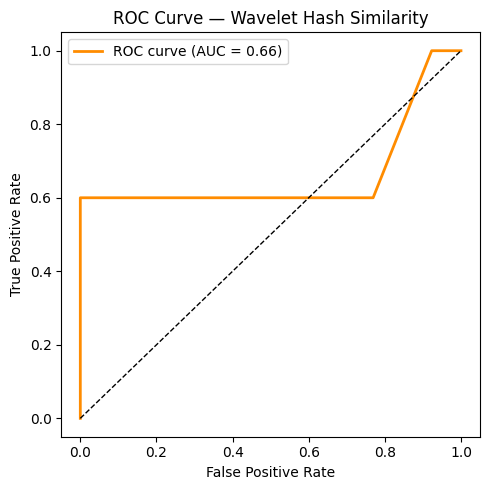

In [23]:
# ROC curve: dùng distance âm (càng nhỏ = càng similar = score cao)
scores = [-d for d in distances]   # flip: smaller distance → higher score

fpr, tpr, thresholds = roc_curve(labels, scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Wavelet Hash Similarity')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=120)
plt.show()

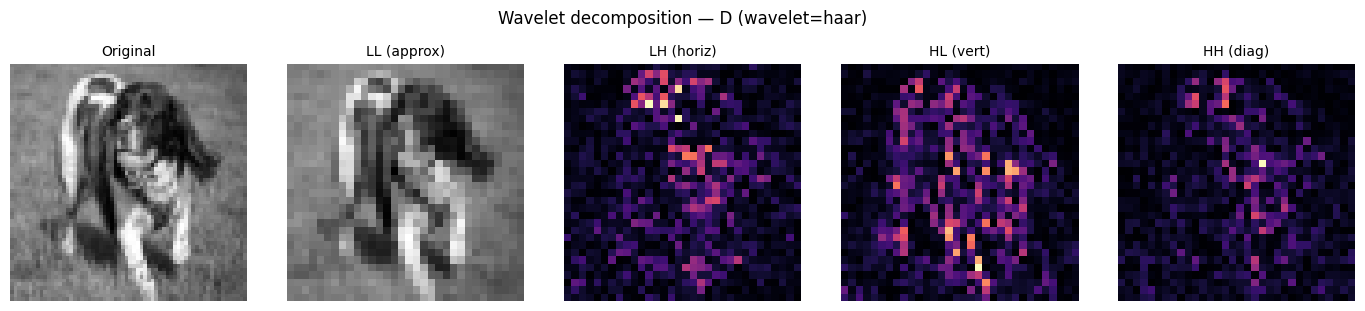

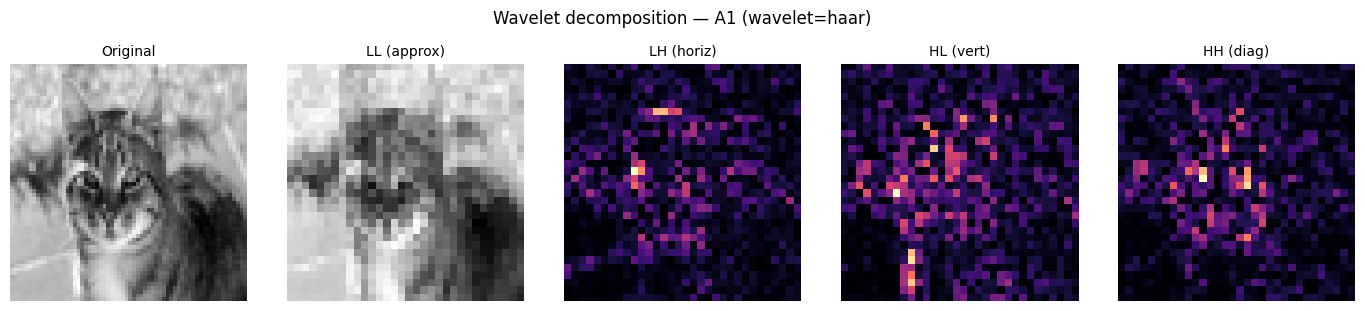

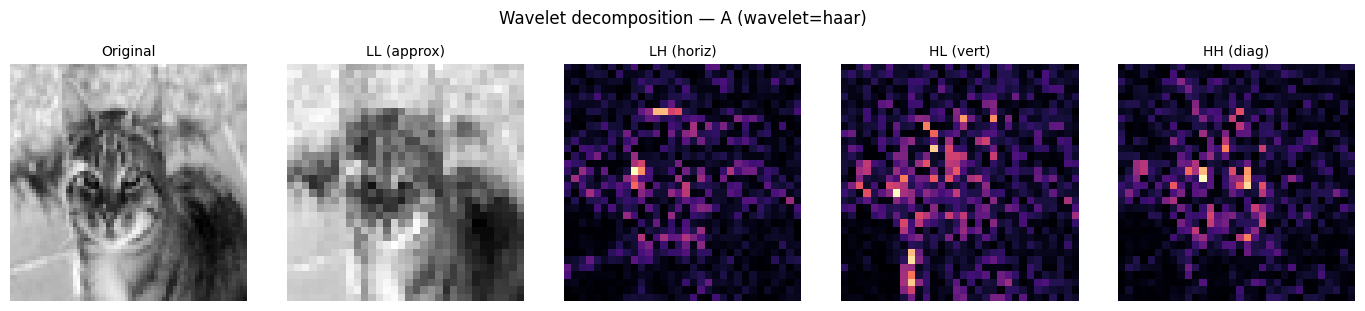

In [25]:
def show_wavelet_decomposition(img_array, name='Image', wavelet='haar'):
    """Hiển thị ảnh gốc và 4 sub-bands của DWT."""
    img = img_array.astype(np.float32)
    LL, (LH, HL, HH) = pywt.dwt2(img, wavelet)
    
    fig, axes = plt.subplots(1, 5, figsize=(14, 3))
    titles = ['Original', 'LL (approx)', 'LH (horiz)', 'HL (vert)', 'HH (diag)']
    data   = [img, LL, np.abs(LH), np.abs(HL), np.abs(HH)]
    cmaps  = ['gray', 'gray', 'magma', 'magma', 'magma']
    
    for ax, title, d, cmap in zip(axes, titles, data, cmaps):
        ax.imshow(d, cmap=cmap)
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    
    plt.suptitle(f'Wavelet decomposition — {name} (wavelet={wavelet})', y=1.02)
    plt.tight_layout()
    plt.savefig(f'wavelet_{name}.png', dpi=120, bbox_inches='tight')
    plt.show()

# Hiển thị decomposition cho 2 ảnh bất kỳ (ưu tiên A1, B1 nếu tồn tại)
image_names = list(images.keys())
if len(image_names) >= 1:
    name1 = 'A1' if 'A1' in images else image_names[0]
    name2 = 'D' if 'D' in images and 'D' != name1 else next((n for n in image_names if n != name1), image_names[0]) 
    show_wavelet_decomposition(images[name2], name=name2)
    show_wavelet_decomposition(images[name1], name=name1)
if len(image_names) >= 2:
    # Tìm một ảnh khác với name1, ưu tiên 'B1' nếu có
    if 'B1' in images and 'B1' != name1:
        name2 = 'B1'
    else:
        name2 = next((n for n in image_names if n != name1), image_names[0])
    show_wavelet_decomposition(images[name2], name=name2)

Visualizing similar pair: ('A3', 'A4')


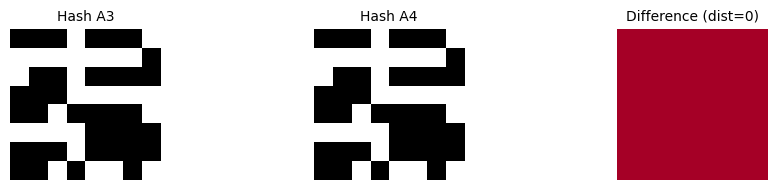

Visualizing non-similar pair: ('A', 'B')


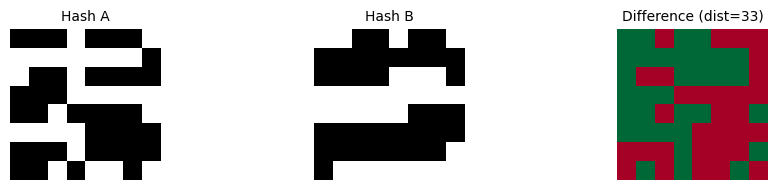

In [26]:
def compare_hashes_visual(name1, name2, hashes):
    h1, h2 = hashes[name1], hashes[name2]
    diff = (h1 != h2).astype(int)
    dist = diff.sum()
    
    fig, axes = plt.subplots(1, 3, figsize=(10, 2))
    for ax, data, title in zip(axes,
            [h1.reshape(8, -1), h2.reshape(8, -1), diff.reshape(8, -1)],
            [f'Hash {name1}', f'Hash {name2}', f'Difference (dist={dist})']):
        ax.imshow(data, cmap='RdYlGn' if 'Diff' in title else 'binary', vmin=0, vmax=1)
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Chọn cặp similar và not-similar để minh hoạ
if hashes:
    # Tìm một cặp similar nếu có
    sim_pair = None
    if 'similar_pairs' in globals() and similar_pairs:
        sim_pair = next(iter(similar_pairs))
    elif len(hashes) >= 2:
        # fallback: lấy 2 ảnh đầu tiên
        keys = list(hashes.keys())
        sim_pair = (keys[0], keys[1])

    # Tìm một cặp non-similar nếu có từ danh sách pairs/labels
    nonsim_pair = None
    if 'pairs' in globals() and 'labels' in globals():
        for (p, lbl) in zip(pairs, labels):
            if lbl == 0:
                nonsim_pair = p
                break
    if nonsim_pair is None and len(hashes) >= 2:
        keys = list(hashes.keys())
        nonsim_pair = (keys[0], keys[-1])

    if sim_pair is not None:
        print(f"Visualizing similar pair: {sim_pair}")
        compare_hashes_visual(sim_pair[0], sim_pair[1], hashes)
    else:
        print("Không tìm được cặp similar để minh hoạ.")

    if nonsim_pair is not None:
        print(f"Visualizing non-similar pair: {nonsim_pair}")
        compare_hashes_visual(nonsim_pair[0], nonsim_pair[1], hashes)
    else:
        print("Không tìm được cặp non-similar để minh hoạ.")
else:
    print("Không có hash nào để so sánh.")